# More Advanced Techniques (and Architectures)
We have thus far studied a number of convolutional networks for performing classification, specifically using the Fashion MNIST dataset. However, as the classification problem becomes more complicated, it will require more complicated architectures and more involved methods for regularizing the data. For instance, object recognition requires more knowledge than simple handwriting digits (as in the case of recognizing shirts in Fashion MNIST). The complexities of the picture are more varied, color has an influence, and much more. Therefore, the simple convolutions that we used before might not be expressive enough without a number of additional layers. 

Let's try some of these techniques with Tiny Imagenet (a subset of ImageNet Data with 64x64 sized images and 200 classes). Some of these concepts we have already talked about, such as different initializations and different regularizers. Namely, we will cover these concepts:

- Expansion
- Initialization
- Parallel Pathways
- Building Blocks from More Advanced Networks (bypass, branching, etc.)

![resnet](PDF_Slides/CNN_Summary.png)

After going through this tutorial, you will have an understanding of how to use some of the more advanced techniques--however we are limited here by the hardware and time in lecture. Many modern architectures can take days/weeks to train and are extremely deep (look at the 100+ layers of ResNet-112). However, some of the architectures from ~2013 and ~2014 are manageable to investigate and take only a few hours to train. We will cover a few concepts for getting models up and running, and maybe even use more some complicated architectures. Let's get started! 

This is also an excellent tutorial with even more information than I am showing for the fine tuning techniques:
- https://cambridgespark.com/content/tutorials/neural-networks-tuning-techniques/index.html

In [1]:
import os, sys
os.environ['KMP_DUPLICATE_LIB_OK']='True'
os.environ['PYTORCH_ENABLE_MPS_FALLBACK']='True'

from sklearn import datasets, metrics
from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('ggplot')

import numpy as np
import torch 
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim

print('System', sys.version)
print('Torch version:',torch.__version__)

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

if torch.cuda.is_available(): device = torch.device("cuda")
elif torch.mps.is_available(): device = torch.device("mps")
else: device = torch.device("cpu")
print(f'Using {device}')

System 3.12.13 | packaged by Anaconda, Inc. | (main, Jul  9 2026, 14:29:01) [Clang 20.1.8 ]
Torch version: 2.13.0
CUDA available: False
MPS available: True
MPS built: True
Using mps


In [2]:
# Utility functions for summarizing outputs from models
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    
    plt.ylabel('Accuracy %')
    plt.title('Training')
    plt.plot(history['test_acc'], label='validation')
    plt.title('Accuracy')
    plt.legend()
    
    plt.subplot(1,2,2)
    plt.plot(history['train_loss'], label='training')
    plt.ylabel('Training Loss')
    plt.xlabel('epochs')
    
    plt.plot(history['test_loss'], label='validation')
    plt.xlabel('epochs')
    plt.title('Loss')
    plt.legend()
    plt.show()


def train_model(model, train_loader, test_loader, criterion, optimizer, epochs, print_every=10):
    history = {
        "train_loss": [],
        "test_loss": [],
        "test_acc": []
    }
    for epoch in range(epochs): 
        total_loss = 0
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            optimizer.zero_grad()
            predictions = model(batch_X)
            loss = criterion(predictions, batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
    
        history["train_loss"].append(total_loss / len(train_loader))

        total_loss = 0
        predictions = []
        test_labels = []
        model.eval()
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)
                yhat = model(batch_X)
                loss = criterion(yhat, batch_y)
                # Adding the ".data" to the tensor removes operation from autograd tracking
                _, ypreds = torch.max(yhat.data, 1)
                batch_y = batch_y.data # already an integer
                
                predictions.extend(ypreds.cpu())
                test_labels.extend(batch_y.cpu())

                total_loss += loss.item()
            history["test_loss"].append(total_loss / len(test_loader))
            history["test_acc"].append( metrics.accuracy_score(test_labels, predictions) )
            
        if epoch%print_every == 0 or epoch>=epochs-1: 
            # print out some results  
            print(f"Epoch {epoch+1} Loss: {history["train_loss"][-1]:.4f}", end=" ")
            print(f"Test Accuracy: {history["test_acc"][-1]:.4f}")

    return history

def compare_models(models, test_loader, fig_size=(15,5), labels='auto'):
    ''' Plot confusion matrices for each model, with names
    '''
    plt.figure(figsize=fig_size)

    # plot confusion matrices 
    num_plots = len(models)
    i = 1

    for model in models:
        predictions = []
        test_labels = []
        model.eval()
        with torch.no_grad():
            for batch_X, batch_y in test_loader:
                batch_X = batch_X.to(device, non_blocking=True)
                batch_y = batch_y.to(device, non_blocking=True)
                
                yhat = model(batch_X)
                # Adding the ".data" to the tensor removes operation from autograd tracking
                # perform the arg_max
                _, ypreds = torch.max(yhat.data, 1)
                batch_y = batch_y.data # already an integer
                
                predictions.extend(ypreds.cpu())
                test_labels.extend(batch_y.cpu())
    
            acc = metrics.accuracy_score(test_labels,predictions)
    
            cm = metrics.confusion_matrix(test_labels,predictions)
            cm = cm/np.sum(cm,axis=1)[:,np.newaxis]
            
            plt.subplot(1,num_plots,i)
            
            sns.heatmap(cm, annot=False,xticklabels=labels, yticklabels=labels)
            plt.title(f'{model.name}: {acc:.4f}')
            i += 1

Now let's load in a more diverse, harder to classify dataset.

**Labels**
We will start to investigate performance using the Tiny ImageNet dataset. This dataset consists of 200 classes from original ImageNet dataset. Each class is having 500 train images, 50 validation images. So 100,000 images for training and 10,000 images for validation.

The dataset is surprisingly difficult to classify upon, with most models achieving top-1 accuracies of less than 50%. A list of models and performances is given at the link below. One aspect of difficulty is that one cannot use transfer learning from large models, becasue these models are typically trained on the original ImageNet data (i.e., these data appear in ImageNet, so transfer learning is not advisable). As such, this provides a challenging test case to learn from. 
- https://github.com/meet-minimalist/TinyImageNet-Benchmarks

You can find "evidence" of strong performance on TinyImagenet, for example here: https://arxiv.org/html/2505.08259v1. In this paper, they used ViT (which has the ImageNet training set as part of its original training). It acheived an amazing accuracy > 90%. All they had to do was train and test on the same data. 

Each training and test example is assigned to one of 200 labels. For instance here is a small set of sample labels.
- 'n02085620': 'Chihuahua',
- 'n02094433': 'Yorkshire',
- 'n02099601': 'golden',
- 'n02099712': 'Labrador',
- 'n02106662': 'German',
- 'n02113799': 'standard',
- 'n02123045': 'tabby,',
- 'n02123394': 'Persian',
- 'n02124075': 'Egyptian',
- 'n02125311': 'cougar,',
- 'n02129165': 'lion,',
- 'n02132136': 'brown',
- 'n02165456': 'ladybug,',
- ... and many other classes. 

In [26]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

def load_tiny_imagenet(user_transform=None):

    if user_transform == None:
        # Define image transformations (64x64 size for Tiny ImageNet)
        train_transform = transforms.Compose([
            transforms.RandomCrop(64, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        
        test_transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    else:
        train_transform = user_transform
        test_transform = user_transform
    
    full_train_dataset = datasets.ImageFolder(root='large_data/tiny-imagenet-200/train', transform=train_transform)
    full_test_dataset  = datasets.ImageFolder(root='large_data/tiny-imagenet-200/train', transform=test_transform)
    
    indices = list(range(len(full_train_dataset)))
    targets = full_train_dataset.targets
    
    train_idx, test_idx = train_test_split(
        indices,
        test_size=0.2,          # 80% train, 20% test
        random_state=42,
        stratify=targets        # Ensures balanced classes
    )
    
    train_set = Subset(full_train_dataset, train_idx)
    test_set  = Subset(full_test_dataset, test_idx)
    
    train_loader = DataLoader(train_set, batch_size=64, shuffle=True,  pin_memory=False)
    test_loader  = DataLoader(test_set,  batch_size=64, shuffle=False, pin_memory=False)

    return train_loader, test_loader, full_train_dataset.classes

train_loader, test_loader, class_names = load_tiny_imagenet()

In [4]:
NUM_CLASSES = len(class_names)
print(NUM_CLASSES)

dict_class_names_to_description = {}
with open('large_data/tiny-imagenet-200/words.txt', 'r') as file:
    # Read each line from the file
    for line in file:
        vals = line.strip().split()
        key = vals[0]
        if key in class_names:
            dict_class_names_to_description[key] = vals[1]
            
dict_class_names_to_description

200


{'n01443537': 'goldfish,',
 'n01629819': 'European',
 'n01641577': 'bullfrog,',
 'n01644900': 'tailed',
 'n01698640': 'American',
 'n01742172': 'boa',
 'n01768244': 'trilobite',
 'n01770393': 'scorpion',
 'n01774384': 'black',
 'n01774750': 'tarantula',
 'n01784675': 'centipede',
 'n01855672': 'goose',
 'n01882714': 'koala,',
 'n01910747': 'jellyfish',
 'n01917289': 'brain',
 'n01944390': 'snail',
 'n01945685': 'slug',
 'n01950731': 'sea',
 'n01983481': 'American',
 'n01984695': 'spiny',
 'n02002724': 'black',
 'n02056570': 'king',
 'n02058221': 'albatross,',
 'n02074367': 'dugong,',
 'n02085620': 'Chihuahua',
 'n02094433': 'Yorkshire',
 'n02099601': 'golden',
 'n02099712': 'Labrador',
 'n02106662': 'German',
 'n02113799': 'standard',
 'n02123045': 'tabby,',
 'n02123394': 'Persian',
 'n02124075': 'Egyptian',
 'n02125311': 'cougar,',
 'n02129165': 'lion,',
 'n02132136': 'brown',
 'n02165456': 'ladybug,',
 'n02190166': 'fly',
 'n02206856': 'bee',
 'n02226429': 'grasshopper,',
 'n02231487

Training
Image size: torch.Size([3, 64, 64]) , Classes: 200


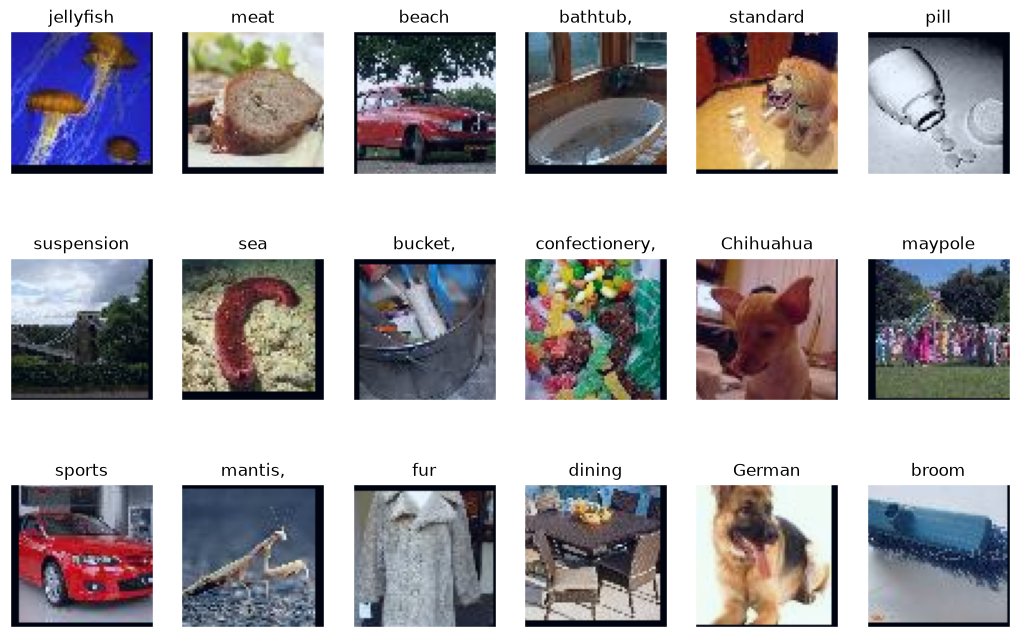

Validation
Image size: torch.Size([3, 64, 64]) , Classes: 200


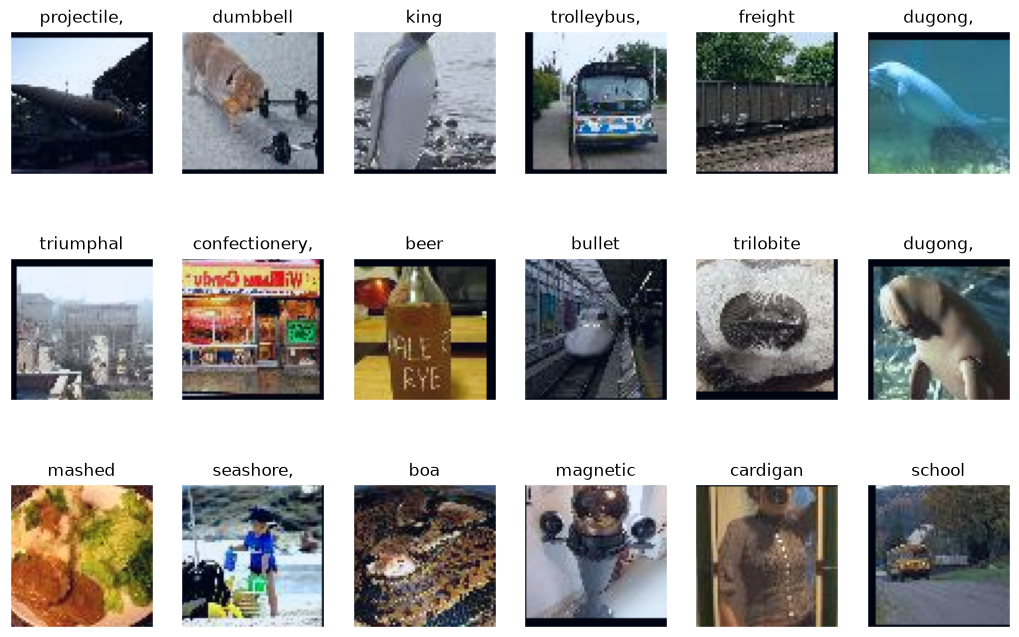

In [5]:
# a helper plotting function
def plot_gallery(ds, h, w, n_row=3, n_col=6):
    """Helper function to plot a gallery of portraits"""
    img_sample, label_sample = next(iter(train_loader))
    images = img_sample.numpy()
    
    img_wh = img_sample[0].shape[1] # get the width and height for the image
    print('Image size:',img_sample[0].shape,', Classes:',200)
    titles = [dict_class_names_to_description[class_names[x]] for x in label_sample.numpy()] 
    
    plt.figure(figsize=(1.7 * n_col, 2.3 * n_row))
    plt.subplots_adjust(bottom=0, left=.01, right=.99, top=.90, hspace=.35)
    for i in range(n_row * n_col):
        plt.subplot(n_row, n_col, i + 1)
        mn, mx = images[i].min(), images[i].max()
        images[i] = (images[i]-mn)/(mx-mn)
        plt.imshow(np.transpose(images[i].squeeze(),(1, 2, 0)))
        plt.title(titles[i], size=12)
        plt.xticks(())
        plt.yticks(())

    plt.show()

print('Training')
plot_gallery(train_loader, 64, 64) 
print('Validation')
plot_gallery(test_loader, 64, 64) 

## Starting simple
Let's first start by using data expansion with an architecture similar to AlexNet.

In [6]:
class ImageCNNCustom(nn.Module):
    def __init__(self, input_shape=(3,64,64), filters_per_conv_layer=[32,64,128], dense_layer_size = 256,
                 use_dropout=False, num_classes=200, name='CustomCNN'):
        super().__init__()
        self.name = name

        in_channels, h, w = input_shape
        layers = []

        # Build Convolutional Blocks dynamically
        current_channels = in_channels
        
        for out_channels in filters_per_conv_layer:
            layers.extend([
                nn.Conv2d(current_channels, out_channels, kernel_size=3, stride=2, padding=1),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(kernel_size=2, stride=2)
            ])
            
            if use_dropout:
                layers.append(nn.Dropout2d(p=0.25))
                
            current_channels = out_channels

        self.feature_extractor = nn.Sequential(*layers)

        # Run a dummy tensor through feature_extractor to determine Linear layer input size
        with torch.no_grad():
            dummy_input = torch.zeros(1, in_channels, h, w)
            dummy_output = self.feature_extractor(dummy_input)
            flattened_dim = dummy_output.numel()
        
        # Build Classifier Head
        classifier_layers = [
            nn.Flatten(),
            nn.Linear(flattened_dim, dense_layer_size),
            nn.ReLU(inplace=True)
        ]
        
        if use_dropout:
            classifier_layers.append(nn.Dropout(p=0.5))  # Typically higher on dense
            
        classifier_layers.append(nn.Linear(dense_layer_size, num_classes))
        
        self.classifier = nn.Sequential(*classifier_layers)

    def forward(self, x):
        x = self.feature_extractor(x)
        x = self.classifier(x)
        return x

cnn = ImageCNNCustom().to(device)
cnn

ImageCNNCustom(
  (feature_extractor): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=128, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=256, out_features=200, bias=True)
  )
)

Epoch 1 Loss: 4.7089 Test Accuracy: 0.1067
Epoch 4 Loss: 3.6553 Test Accuracy: 0.1979
Epoch 7 Loss: 3.4218 Test Accuracy: 0.2235
Epoch 10 Loss: 3.2966 Test Accuracy: 0.2336
Epoch 13 Loss: 3.2107 Test Accuracy: 0.2409
Epoch 16 Loss: 3.1583 Test Accuracy: 0.2442
Epoch 19 Loss: 3.1171 Test Accuracy: 0.2493
Epoch 22 Loss: 3.0867 Test Accuracy: 0.2529
Epoch 25 Loss: 3.0505 Test Accuracy: 0.2610


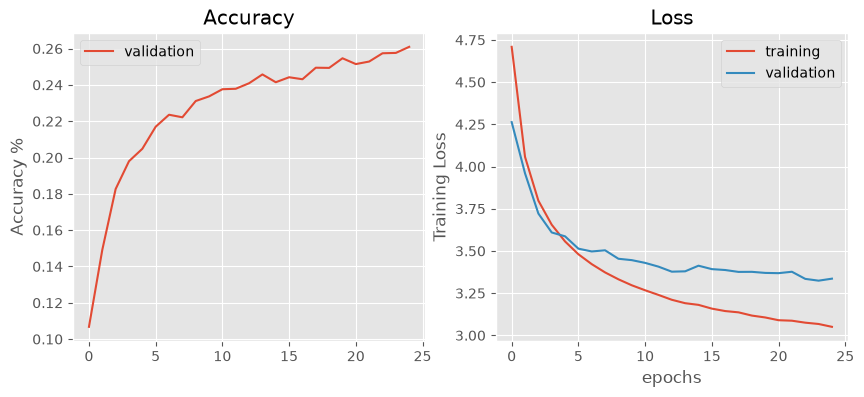

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)
history = train_model(cnn, train_loader, test_loader, criterion, optimizer, epochs=25, print_every=3)
plot_history(history)

In [8]:

class LayerNorm2d(nn.Module):
    """
    LayerNorm applied over the channel dimension for 2D inputs of shape (N, C, H, W),
    matching modern CNN designs (e.g., ConvNeXt).
    """
    def __init__(self, num_channels: int, eps: float = 1e-6):
        super().__init__()
        self.norm = nn.LayerNorm(normalized_shape=num_channels, eps=eps)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Compute along channel
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        x = x.permute(0, 3, 1, 2)
        return x
        

class TinyAlexNet(nn.Module):
    def __init__(self, num_classes: int = 200, dropout: float = 0.5):
        super().__init__()
        self.name = 'TinyAlexnet'
        self.features = nn.Sequential(
            #                        strided conv     max pool 
            # Conv 1: (3, 64, 64) -> (32, 32, 32) -> (32, 16, 16)
            nn.Conv2d(3, 32, kernel_size=5, stride=2, padding=2),
            LayerNorm2d(32),
            nn.GELU(approximate='tanh'),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv 2: (32, 16, 16) -> (64, 16, 16) -> (64, 8, 8)
            nn.Conv2d(32, 64, kernel_size=5, padding=2),
            LayerNorm2d(64),
            nn.GELU(approximate='tanh'),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Conv 3: (64, 8, 8) -> (128, 8, 8) > (128, 4, 4)
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            LayerNorm2d(128),
            nn.GELU(approximate='tanh'),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
        )
        
        # Spatial resolution: 128 * 4 * 4 = 2048 features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(128 * 4 * 4, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

alexnet = TinyAlexNet().to(device)
alexnet

TinyAlexNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (1): LayerNorm2d(
      (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (2): GELU(approximate='tanh')
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (5): LayerNorm2d(
      (norm): LayerNorm((64,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (6): GELU(approximate='tanh')
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): LayerNorm2d(
      (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (10): GELU(approximate='tanh')
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inpla

Epoch 1 Loss: 4.8630 Test Accuracy: 0.0775
Epoch 4 Loss: 3.5834 Test Accuracy: 0.2245
Epoch 7 Loss: 3.2022 Test Accuracy: 0.2804
Epoch 10 Loss: 2.9688 Test Accuracy: 0.3171
Epoch 13 Loss: 2.8059 Test Accuracy: 0.3371
Epoch 16 Loss: 2.6676 Test Accuracy: 0.3527
Epoch 19 Loss: 2.5580 Test Accuracy: 0.3660
Epoch 22 Loss: 2.4643 Test Accuracy: 0.3716
Epoch 25 Loss: 2.3928 Test Accuracy: 0.3783


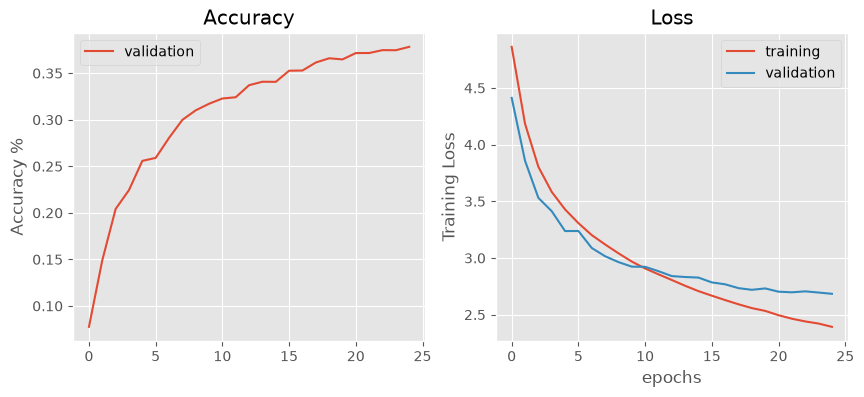

In [9]:
# now fit with random augmentations applied during training only
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(alexnet.parameters(), lr=1e-3)
history = train_model(alexnet, train_loader, test_loader, criterion, optimizer, epochs=25, print_every=3)
plot_history(history)

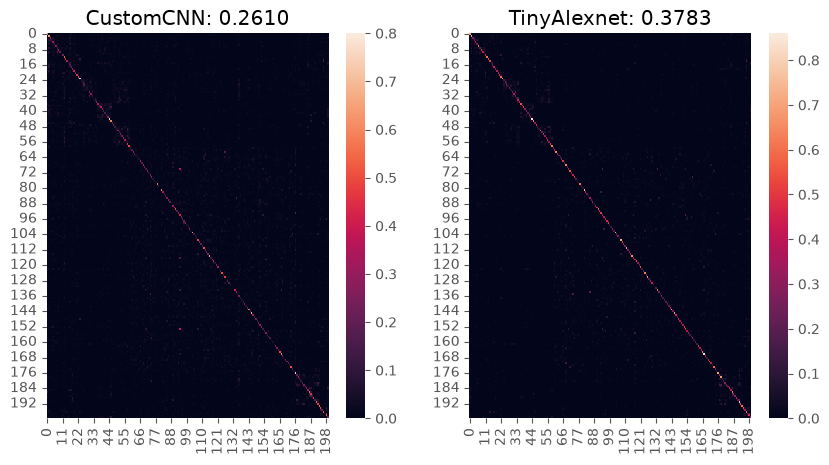

In [10]:
compare_models([cnn,alexnet], test_loader, fig_size=(10,5))

_____
The above AlexNet model is not too bad, but we might need to be more aggressive with preventing overfitting. To help, we will use more Dropout, Image Augmentations, and some L2 weight regularizations per layer.

Moreover, we need to run for more epochs. But how can we know if we converged? Here we can incorporate Early Stopping using one of the keras calback functions.

Let's try these techniques with the AlexNet model from before.

# ConvNext Pathways
Now lets do the exact same thing, but with blocks that process the data in multiple pathways, mirroring ConvNext wherever possible (but on a smaller scale). From lecture, you will see the following properties. 

ConvNext is an architecture that competes and many times beats out transformers, but is only convolution some simple ideas that morph toward x-former
- Patchify: make 4x4 conv with stride of 4 (patch) as an entry point (stage one below, handles initial downsampling by factor of 4)
- Throughout Architecture:
  - Layer Normalization (along channels)
  - Gaussian Error Linear Unit (GELU)for activations
- Process these on four sets of resolutions for each stage (downsampling)
- For each Stage: We define a `ConvNextBlock` of Separable Convolution followed by reverse bottleneck (and apply the block multiple times)
  - `Conv2D(in_channels = out_channels = groups)` for Separable convolution
  -  Reverse bottleneck expands and collapses with 1x1 kernels
  -  These parts of the block do not change spatial resolution, such that residual pathway can be added in parallel to block operations
  -  This Block is applied multiple times at each stage (however, in my implementation below, I only apply the operation one time for each stage to reduce the number of layers and parameters)
- Between each stage, we downsample the spatial resoution and expand the channels, then continue processing as above. In the actual ConvNext architecture, the amount of expansion and the number of blocks in each stage is a critical part of the architecture. 
 

In [11]:
class TinyConvNext(nn.Module):
    def __init__(self, num_classes: int = 200, dropout: float = 0.5):
        super().__init__()
        self.name = 'TinyConvNext'

        # Stage 1, Entry Downsampling: (3, 64, 64) -> (32, 16, 16)
        self.stage1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=4,stride=4),
            LayerNorm2d(32)
        )
            
        # will add residual to this in forward, no change to size, (32, 16, 16)
        self.stage2 = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=5, stride=1, padding=2, groups=32), # separable convolution
            LayerNorm2d(32),
            nn.Conv2d(32, 96, kernel_size=1, stride=1, padding=0), # expand
            nn.GELU(approximate='tanh'),   
            nn.Conv2d(96, 32, kernel_size=1, stride=1, padding=0), # contract            
        )

        # transition stage 2 to 3, (32, 16, 16) -> (64, 8, 8)
        self.project2_3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=1, stride=2, padding=0), # project path
        )

        self.transition2_3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=5, stride=1, padding=2, groups=32), # separable convolution
            LayerNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, padding=0), # expand
            nn.GELU(approximate='tanh'),   
            nn.Conv2d(128, 64, kernel_size=1, stride=1, padding=0), # contract  
            LayerNorm2d(64),
            nn.Conv2d(64, 64, kernel_size=1, stride=2, padding=0), # downsample
        )

        # will add residual to this in forward, no change to size
        self.stage3 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=5, stride=1, padding=2, groups=64), # separable convolution
            LayerNorm2d(64),
            nn.Conv2d(64, 128, kernel_size=1, stride=1, padding=0), # expand
            nn.GELU(approximate='tanh'),   
            nn.Conv2d(128, 64, kernel_size=1, stride=1, padding=0), # contract            
        )

        # transition stage 3 to 4, (64, 8, 8) -> (128, 4, 4)
        self.project3_4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=1, stride=2, padding=0), # project path
        )

        self.transition3_4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, stride=1, padding=2, groups=64), # separable convolution
            LayerNorm2d(128),
            nn.Conv2d(128, 256, kernel_size=1, stride=1, padding=0), # expand
            nn.GELU(approximate='tanh'),   
            nn.Conv2d(256, 128, kernel_size=1, stride=1, padding=0), # contract  
            LayerNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=1, stride=2, padding=0), # downsample
        )

        # will add residual to this in forward, no change to size, (128, 4, 4)
        self.stage4 = nn.Sequential(
            nn.Conv2d(128, 128, kernel_size=5, stride=1, padding=2, groups=128), # separable convolution
            LayerNorm2d(128),
            nn.Conv2d(128, 256, kernel_size=1, stride=1, padding=0), # expand
            nn.GELU(approximate='tanh'),   
            nn.Conv2d(256, 128, kernel_size=1, stride=1, padding=0), # contract            
        )
        
        # Spatial resolution: 128 * 4 * 4 = 2048 features
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(128 * 4 * 4, 1024),
            nn.LayerNorm(1024),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.LayerNorm(512),
            nn.ReLU(inplace=True),
            nn.Linear(512, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # input stem
        residual = self.stage1(x)

        # stage 2
        x = self.stage2(residual)
        x = x + residual

        # transition 2 to 3
        residual = self.project2_3(x)
        x = self.transition2_3(x)
        x = x + residual

        # stage 3
        residual = x
        x = self.stage3(residual)
        x = x + residual

        # transition 3 to 4
        residual = self.project3_4(x)
        x = self.transition3_4(x)
        x = x + residual

        residual = x
        x = self.stage4(residual)
        x = x + residual

        x = torch.flatten(x, 1)
        x = self.classifier(x) 
        
        return x

convnext = TinyConvNext().to(device)
convnext


TinyConvNext(
  (stage1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(4, 4))
    (1): LayerNorm2d(
      (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True, bias=True)
    )
  )
  (stage2): Sequential(
    (0): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=32)
    (1): LayerNorm2d(
      (norm): LayerNorm((32,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (2): Conv2d(32, 96, kernel_size=(1, 1), stride=(1, 1))
    (3): GELU(approximate='tanh')
    (4): Conv2d(96, 32, kernel_size=(1, 1), stride=(1, 1))
  )
  (project2_3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2))
  )
  (transition2_3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), groups=32)
    (1): LayerNorm2d(
      (norm): LayerNorm((64,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (2): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (3): GELU(approximate='tanh')
    (4): Conv2

Epoch 1 Loss: 4.8062 Test Accuracy: 0.0867
Epoch 4 Loss: 3.7434 Test Accuracy: 0.2035
Epoch 7 Loss: 3.3481 Test Accuracy: 0.2549
Epoch 10 Loss: 3.1238 Test Accuracy: 0.2814
Epoch 13 Loss: 2.9560 Test Accuracy: 0.3003
Epoch 16 Loss: 2.8204 Test Accuracy: 0.3175
Epoch 19 Loss: 2.7122 Test Accuracy: 0.3282
Epoch 22 Loss: 2.6099 Test Accuracy: 0.3321
Epoch 25 Loss: 2.5321 Test Accuracy: 0.3372


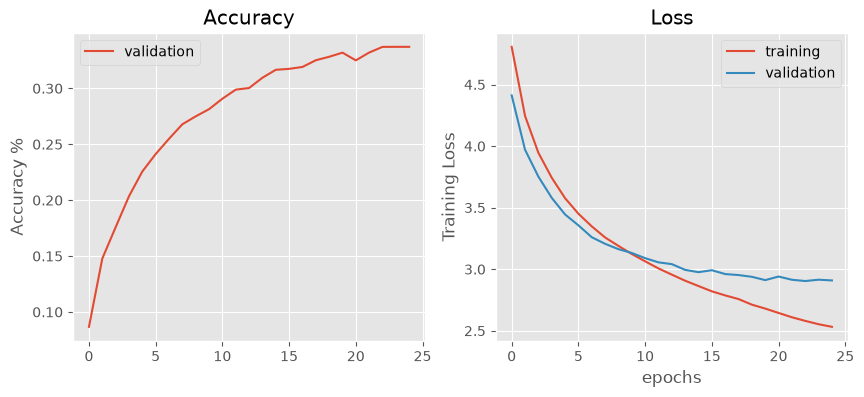

CPU times: user 33min 24s, sys: 12min 16s, total: 45min 40s
Wall time: 2h 19min 42s


In [12]:
%%time

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(convnext.parameters(), lr=1e-3)
history = train_model(convnext, train_loader, test_loader, criterion, optimizer, epochs=25, print_every=3)
plot_history(history)

Epoch 1 Loss: 2.5108 Test Accuracy: 0.3392
Epoch 4 Loss: 2.4282 Test Accuracy: 0.3397
Epoch 7 Loss: 2.3626 Test Accuracy: 0.3513
Epoch 10 Loss: 2.3010 Test Accuracy: 0.3525
Epoch 13 Loss: 2.2464 Test Accuracy: 0.3535
Epoch 16 Loss: 2.1956 Test Accuracy: 0.3534
Epoch 19 Loss: 2.1480 Test Accuracy: 0.3568
Epoch 22 Loss: 2.1125 Test Accuracy: 0.3590
Epoch 25 Loss: 2.0573 Test Accuracy: 0.3589


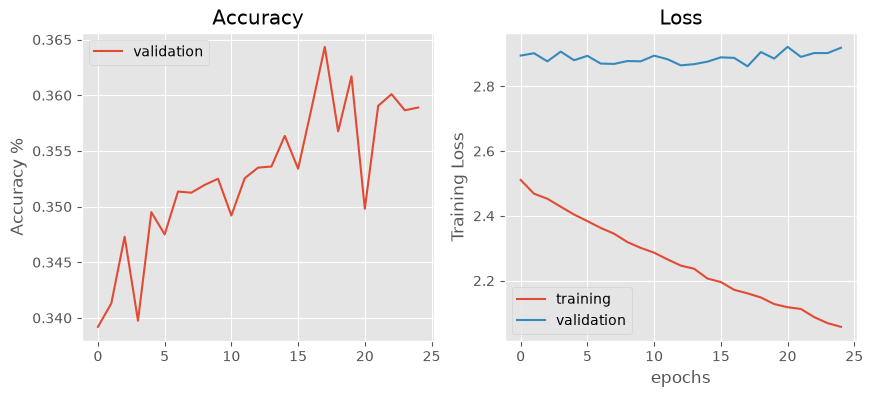

In [14]:
# perform some additional training, to see if we can saturate performance
history = train_model(convnext, train_loader, test_loader, criterion, optimizer, epochs=25, print_every=3)
plot_history(history)

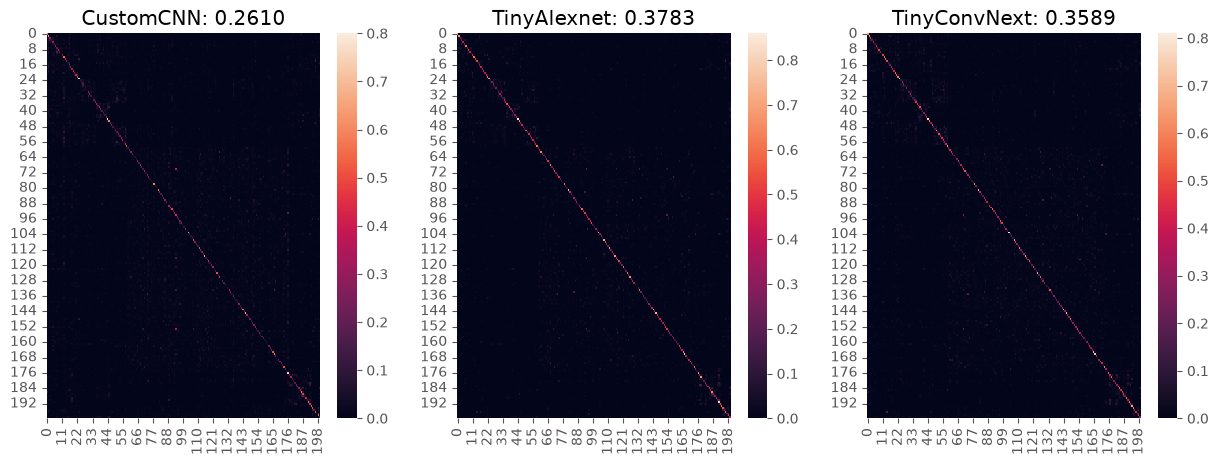

In [15]:
compare_models([cnn,alexnet,convnext], test_loader, fig_size=(15,5))

# Transfer Learning with Hugging Face
Now let's use some pre-trained networks rather than building these architectures from scratch. Recall that in pyTorch, we need to create the architecture and then populate the weights with a state dictionary. There are many architectures available to use that are posted on hugging face. Let's load up a variant of the ConvNext architecture and do some fine tuning.

In [93]:
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# Load the pre-trained ConvNeXt model with default weights
weights = ConvNeXt_Tiny_Weights.DEFAULT
model = convnext_tiny(weights=weights)

# also need to use the correct transforms for this model:
base_transforms = weights.transforms()
train_loader, test_loader, class_names = load_tiny_imagenet(base_transforms)

# let's look at the loaded model
model

ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True, bias=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True, bias=True)
 

In [94]:
# Notice in the model that we have 
#    (model.features) -> (stem block) -> (many CN blocks)
#    (model.avgpool) -> (just pools down to given resolution)
#    (model.classifier) -> the part that is specific to ImageNet, we will replace this

img_sample, label_sample = next(iter(train_loader))
img_sample = img_sample[0:1] # get one image
print('Image Input:', img_sample.shape)

features = model.features(img_sample)
print('Features:',features.shape)

pooled = model.avgpool(features)
print('Pooling:',pooled.shape)

output = model.classifier(pooled)
print('Classifier:',output.shape)

Image Input: torch.Size([1, 3, 224, 224])
Features: torch.Size([1, 768, 7, 7])
Pooling: torch.Size([1, 768, 1, 1])
Classifier: torch.Size([1, 1000])


In [95]:
# model.classifier is a Sequential block:
# model.classifier[0] is LayerNorm2d -- we will keep this
#             -----                  -- here we will use dropout to help prevent overfitting
# model.classifier[1] is Flatten     -- we will move this operation after dropout 
# model.classifier[2] current Linear -- layer we want to replace with new class head

num_features = 768
num_classes = 200  # Replace with your dataset target count

# Overwrite only the specific linear layer inside the sequential block
model.classifier[1] = nn.Dropout(p=0.5)
model.classifier[2] = nn.Flatten(start_dim=1, end_dim=-1) 
model.classifier.append( nn.Linear(num_features, num_classes) ) # new trainable layer!
model = model.to(device)

In [96]:
%%time

from torch.utils.data import TensorDataset

def get_bottleneck(loader, model, shuffle=True):
    # can we also do this with a bottleneck, data loader? Is it faster?
    features_list = []
    labels_list = []
    
    with torch.no_grad():
        model.eval()
        for images, labels in loader:
            images = images.to(device)
            # Forward pass gets features
            bottleneck = model.avgpool(model.features(images))
            
            features_list.append(bottleneck.cpu())
            labels_list.append(labels.cpu())
    
    all_features = torch.cat(features_list, dim=0)
    all_labels = torch.cat(labels_list, dim=0)
    
    return DataLoader(TensorDataset(all_features, all_labels),  batch_size=64, shuffle=shuffle, pin_memory=False )

bottleneck_loader_train = get_bottleneck(train_loader, model, shuffle=True)
bottleneck_loader_test = get_bottleneck(test_loader, model, shuffle=False)

CPU times: user 4min 12s, sys: 2min 54s, total: 7min 7s
Wall time: 14min 46s


Epoch 1 Loss: 3.6602 Test Accuracy: 0.7399
Epoch 2 Loss: 1.5547 Test Accuracy: 0.7802
Epoch 3 Loss: 1.0645 Test Accuracy: 0.7931
Epoch 4 Loss: 0.9212 Test Accuracy: 0.8037
Epoch 5 Loss: 0.8479 Test Accuracy: 0.8077
Epoch 6 Loss: 0.8009 Test Accuracy: 0.8111
Epoch 7 Loss: 0.7661 Test Accuracy: 0.8123
Epoch 8 Loss: 0.7377 Test Accuracy: 0.8151
Epoch 9 Loss: 0.7166 Test Accuracy: 0.8171
Epoch 10 Loss: 0.6981 Test Accuracy: 0.8175


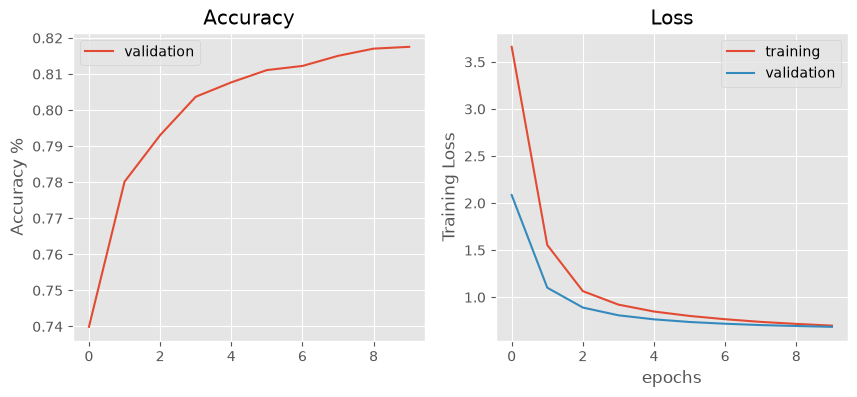

CPU times: user 9.86 s, sys: 2.57 s, total: 12.4 s
Wall time: 15.1 s


In [97]:
%%time

optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()
history = train_model(model.classifier, bottleneck_loader_train, bottleneck_loader_test, criterion, optimizer, epochs=10, print_every=1)
plot_history(history)

Epoch 1 Loss: 0.6119 Test Accuracy: 0.8806
Epoch 2 Loss: 0.4297 Test Accuracy: 0.8864
Epoch 3 Loss: 0.3267 Test Accuracy: 0.8900
Epoch 4 Loss: 0.2649 Test Accuracy: 0.8887
Epoch 5 Loss: 0.2205 Test Accuracy: 0.8900
Epoch 6 Loss: 0.1790 Test Accuracy: 0.8905
Epoch 7 Loss: 0.1528 Test Accuracy: 0.8917
Epoch 8 Loss: 0.1326 Test Accuracy: 0.8924
Epoch 9 Loss: 0.1228 Test Accuracy: 0.8911
Epoch 10 Loss: 0.1107 Test Accuracy: 0.8917
Epoch 11 Loss: 0.1015 Test Accuracy: 0.8922
Epoch 12 Loss: 0.0870 Test Accuracy: 0.8939
Epoch 13 Loss: 0.0849 Test Accuracy: 0.8937
Epoch 14 Loss: 0.0816 Test Accuracy: 0.8931
Epoch 15 Loss: 0.0731 Test Accuracy: 0.8922


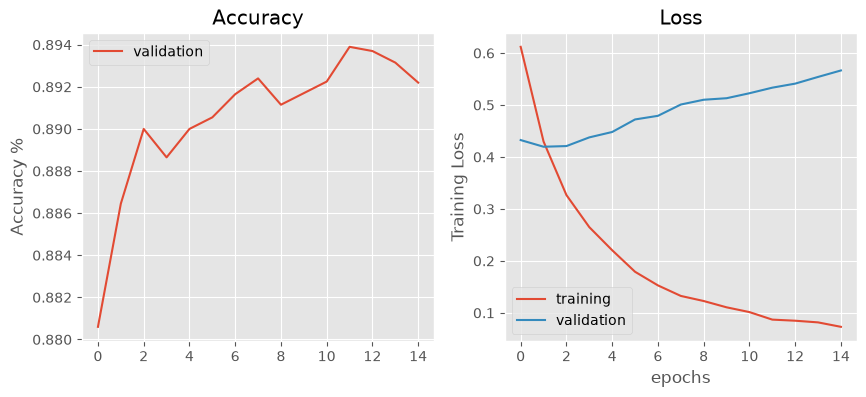

In [98]:
# setup differential fine tuning 
optimizer = optim.AdamW([
    {"params": model.features.parameters(),   "lr": 1e-5},  # small LR for pretrained features
    {"params": model.classifier.parameters(), "lr": 1e-3} # larger LR for the new head
], weight_decay=1e-2)

history = train_model(model, train_loader, test_loader, criterion, optimizer, epochs=15, print_every=1)
plot_history(history)